# Técnicas de Aprendizaje Automático 2026
## Prueba de progreso 1: Predicción de la Calidad del Vino
### Sara Hidalgo Salas
En esta prueba lo que tenemos que hacer es predecir la calidad del vino utilizando dos enfoques: **clasificación** y **regresión**. Se comparará el desempeño de distintos algoritmos y se evaluará cuál es más adecuado para este conjunto de datos.

### Imports

Importamos las librerías necesarias para trabajar con el dataset.

- numpy y pandas → manejo de datos
- matplotlib → gráficos
- sklearn → algoritmos de machine learning
- ucimlrepo → para descargar el dataset de calidad del vino

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from ucimlrepo import fetch_ucirepo

### Carga del dataset

Cargamos el dataset Wine Quality usando la librería ucimlrepo.

x contiene las variables de entrada (propiedades químicas del vino).

y contiene la variable objetivo (quality), que representa la calidad del vino.

In [66]:
wine_quality = fetch_ucirepo(id=186)# descarga del dataset

x = wine_quality.data.features# variables de entrada
y = wine_quality.data.targets# variable objetivo

In [67]:
print(wine_quality.metadata)# mostramos informacion del dataset

print(wine_quality.variables)# aqui mostramos la informacion de las variables

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

## Crear DataFrame

En esta parte juntamos las variables de entrada (`x`) y la variable objetivo (`y`) en una sola tabla asi podemos tener los datos juntos y trabajar de forma mas facil


In [68]:
df_wine = pd.DataFrame(data=pd.concat([x, y], axis=1))# unimos x e y en una sola tabla con concat y unimos las columnas con axis=1

df_wine.head()# mostramos las primeras filas

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [69]:
df_wine["quality"].value_counts()# mostramos cuántos vinos hay de cada calidad

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

## Análisis de correlación

Ahora vamos a calcular la correlación entre las variables del dataset, los valores cercanos a 1 o -1 tendran fuerte correlación positiva o negativa y los  valores cercanos a 0 tienen correlación débil o nula.

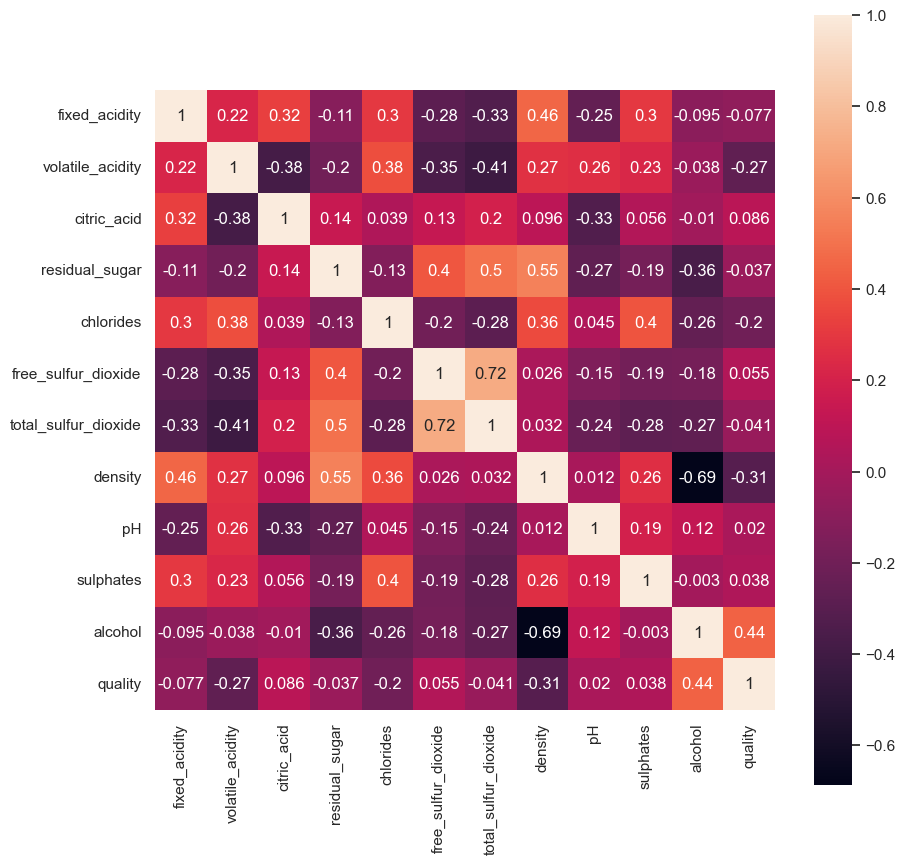

In [70]:
import seaborn as sns

sns.set()

plt.figure(figsize=(10,10))# Ponemos el tamaño 10,10 para poder ver mejor la matriz

sns.heatmap(df_wine.corr(), square=True, annot=True)

plt.show()

## Separación de datos en entrenamiento y prueba

En esta parte separamos las variables de entrada y la variable objetivo.


In [71]:
x = df_wine[['fixed_acidity','volatile_acidity','citric_acid','residual_sugar',
             'chlorides','free_sulfur_dioxide','total_sulfur_dioxide','density',
             'pH','sulphates','alcohol']]# seleccionamos las variables de entrada

y = df_wine['quality']# seleccionamos la variable objetivo

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)# dividimos datos en entrenamiento y prueba

## Escalado de los datos

Antes de entrenar el modelo vamos a escalar los datos, esto ayuda a que todas las características tengan una escala similar, evitando que aquellas con valores más grandes influyan más.

Se hace porque algunas variables tienen valores mucho más grandes que otras.  
Si no las escalamos, esas variables podrían influir demasiado en el modelo.

Para solucionarlo usamos StandardScaler.

In [72]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)# escalamos los datos de entrenamiento
x_test_scaled = scaler.transform(x_test)# escalamos los datos de prueba

# KNN - CLASIFICACION
Ahora utilizaré el algoritmo K-Nearest Neighbors (KNN) para predecir la calidad del vino como un problema de clasificacion.

Este algoritmo lo que hace es clasificar una muestra en función de las clases de sus vecinos más cercanos según una métrica de distancia.

## Búsqueda de los mejores parámetros para KNN

Probamos diferentes valores de:
- Número de vecinos (k)
- Tipo de pesos
- Métrica de distancia

Utilizamos validación cruzada con 4 partes para elegir el mejor modelo.

In [73]:
from sklearn.neighbors import KNeighborsClassifier# importamos el modelo

neighbors_range = range(1, 31)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan', 'minkowski']

best_score = 0
best_params = {}

for weight in weights_options:# probamos todas las combinaciones
    for metric_option in metric_options:
        for neighbors in neighbors_range:

            knn = KNeighborsClassifier(n_neighbors=neighbors, weights=weight, metric=metric_option)# guardamos los parametros actuales en knn
            scores = cross_val_score(knn, x_train_scaled, y_train, cv=4)# guardamos los resultados al hacer la validacion
            mean_score = scores.mean()# calcula la media de los 4 folds o las 4 partes

            if mean_score > best_score:# si el resultado de la media es mejor del que teniamos
                best_score = mean_score# lo guardamos en best_score
                best_params = {'n_neighbors': neighbors, 'weights': weight, 'metric': metric_option}# guardamos los mejores parametros 

print("Best parameters:", best_params)
print("Best cross-validation score:", best_score)

Best parameters: {'n_neighbors': 28, 'weights': 'distance', 'metric': 'manhattan'}
Best cross-validation score: 0.6507616805826968


In [74]:
# guardamos los mejores parametros en knn_final
knn_final = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'], weights=best_params['weights'], metric=best_params['metric'])

In [75]:
# ahora entrenamos el modelo
knn_final.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",28
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [76]:
# predecimos la calidad de los vinos
y_pred = knn_final.predict(x_test_scaled)

## Classification Report

El `classification_report` nos muestra varias métricas para cada clase: 

- **Precision** : qué porcentaje de predicciones de una clase son correctas  
- **Recall** : qué porcentaje de ejemplos reales detecta el modelo 
- **F1-score** : equilibrio entre precision y recall  
- **Support** : número de ejemplos de cada clase

Esto es útil cuando el dataset está desbalanceado.

In [77]:
# con labels se muestra todas las clases que el modelo conoce
# zero_division evita warnings cuando el modelo no predice ninguna muestra de una clase
print(classification_report(y_test, y_pred, labels=knn_final.classes_, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       1.00      0.12      0.21        43
           5       0.69      0.73      0.71       402
           6       0.67      0.77      0.72       597
           7       0.70      0.55      0.62       215
           8       1.00      0.33      0.50        36
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.58      0.36      0.39      1300
weighted avg       0.70      0.68      0.67      1300



Con esto resultados podemos decir que para la calidad de vino 6 por ejemplo:

- Tenemos una **precicion** del 67% por lo que cuadno el modelo dice que el vino es de calidad 6 acierta un 67% de las veces

- Para el **recall** de 77% podemos decir: el modelo detecta correctamente que el 77% es de los vinos de calidad 6

- F1-score es una combinacion entre precision y recall cuanto mas cerca del 1 mejor

- Por ultimo support, este nos dice que para la calidad 6 de vinos tenemos 597 vinos



## Matriz de confusión

En esta parte vamos a crear una matriz de confusión para comparar la calidad real de los vinos con la calidad que predice el modelo.

Esto nos permite ver cuándo el modelo acierta y cuándo se equivoca al clasificar los vinos.

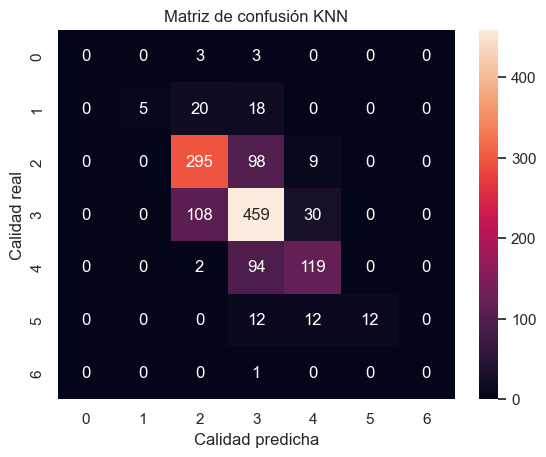

In [78]:
# importamos la función para crear la matriz de confusión
from sklearn.metrics import confusion_matrix

# creamos la matriz de confusion y comparamos valores reales(y_test) y los que hemos predicho antes(y_pred)
cm = confusion_matrix(y_test, y_pred)

# dibujamos la matriz como mapa de calor
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Matriz de confusión KNN")
plt.xlabel("Calidad predicha")
plt.ylabel("Calidad real")

# mostramos el grafico
plt.show()

In [79]:
# calculamos la exactitud del modelo comparando los valores reales(y_test) y los que hemos predicho (y_pred)
acc = accuracy_score(y_test, y_pred)
print("Accuracy en test o sea la exactitud que tiene el modelo es de:", acc)

Accuracy en test o sea la exactitud que tiene el modelo es de: 0.6846153846153846


### Resultado

El modelo KNN obtiene una exactitud aproximada del 68% en el conjunto de prueba.

## NAIVE BAYES - CLASIFICACION
En esta sección vamos a usar el modelo Gaussian Naive Bayes(GaussianNB) para predecir la calidad del vino como un problema de clasificacion.

In [80]:
from sklearn.naive_bayes import GaussianNB# importamos el modelo

In [81]:
nb = GaussianNB()# creamos el modelo de Naive Bayes

In [82]:
nb.fit(x_train_scaled, y_train)# entrenamos el modelo usando los datos de entrenamiento ya escalados

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [83]:
y_pred_nb = nb.predict(x_test_scaled)# predecimos la calidad del vino

## Classification Report

El `classification_report` nos muestra varias métricas para cada clase: 

- **Precision** : qué porcentaje de predicciones de una clase son correctas  
- **Recall** : qué porcentaje de ejemplos reales detecta el modelo 
- **F1-score** : equilibrio entre precision y recall  
- **Support** : número de ejemplos de cada clase

Esto es útil cuando el dataset está desbalanceado.

In [84]:
print(classification_report(y_test, y_pred_nb, labels=nb.classes_, zero_division=0))

              precision    recall  f1-score   support

           3       0.06      0.17      0.09         6
           4       0.13      0.16      0.15        43
           5       0.50      0.61      0.55       402
           6       0.56      0.39      0.46       597
           7       0.37      0.56      0.44       215
           8       0.40      0.06      0.10        36
           9       0.00      0.00      0.00         1

    accuracy                           0.47      1300
   macro avg       0.29      0.28      0.26      1300
weighted avg       0.49      0.47      0.46      1300



Con esto resultados podemos decir que para la calidad de vino 6 por ejemplo:

- Tenemos una **precision** del 56% por lo que cuadno el modelo dice que el vino es de calidad 6 acierta un 56% de las veces

- Para el **recall** de 39% podemos decir: el modelo detecta correctamente que el 39% es de los vinos de calidad 6

- F1-score es una combinacion entre precision y recall cuanto mas cerca del 1 mejor

- Por ultimo support, este nos dice que para la calidad 6 de vinos tenemos 597 vinos



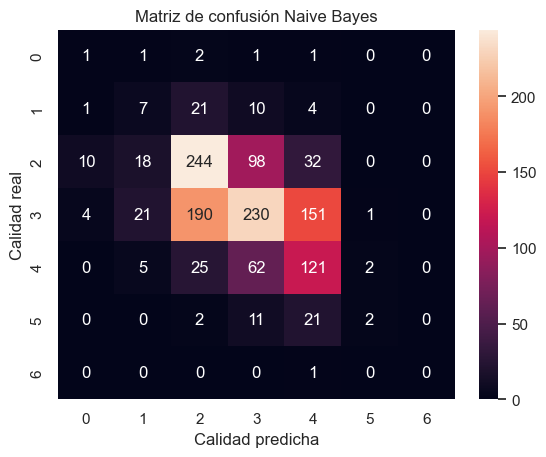

In [85]:
# Matriz de confusión para Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt="d")

plt.title("Matriz de confusión Naive Bayes")
plt.xlabel("Calidad predicha")
plt.ylabel("Calidad real")

plt.show()

In [86]:
acc_nb = accuracy_score(y_test, y_pred_nb)# comparamos los valores, los valores reales(y_test) y los que hemos predicho (y_pred_nb)

print("Accuracy Naive Bayes (exactitud):", acc_nb)

Accuracy Naive Bayes (exactitud): 0.4653846153846154


### Resultado

El modelo Naive Bayes obtiene una exactitud aproximada del 46% en el conjunto de prueba.

## SVM - Clasificación


In [87]:
from sklearn.svm import SVC# importamos el modelo svc (Support Vector Classification)

In [88]:
# creamos el modelo SVM para clasificación con kernel rbf
svm_clf = SVC(kernel='rbf')

In [89]:
# entrenamos el modelo con los datos de entrenamiento escalados
svm_clf.fit(x_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [90]:
# predecimos la calidad de los vinos
y_pred_svm_clf = svm_clf.predict(x_test_scaled)

## Classification Report

El `classification_report` nos muestra varias métricas para cada clase: 

- **Precision** : qué porcentaje de predicciones de una clase son correctas  
- **Recall** : qué porcentaje de ejemplos reales detecta el modelo 
- **F1-score** : equilibrio entre precision y recall  
- **Support** : número de ejemplos de cada clase

Esto es útil cuando el dataset está desbalanceado.

In [91]:
# evaluamos el modelo con clasifiaction report
print(classification_report(y_test, y_pred_svm_clf, labels=svm_clf.classes_, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        43
           5       0.58      0.65      0.61       402
           6       0.55      0.71      0.62       597
           7       0.61      0.20      0.30       215
           8       0.00      0.00      0.00        36
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1300
   macro avg       0.25      0.22      0.22      1300
weighted avg       0.53      0.56      0.52      1300



Con esto resultados podemos decir que para la calidad de vino 6 por ejemplo:

- Tenemos una **precision** del 55% por lo que cuadno el modelo dice que el vino es de calidad 6 acierta un 55% de las veces

- Para el **recall** de 71% podemos decir: el modelo detecta correctamente que el 71% es de los vinos de calidad 6

- F1-score es una combinacion entre precision y recall cuanto mas cerca del 1 mejor

- Por ultimo support, este nos dice que para la calidad 6 de vinos tenemos 597 vinos



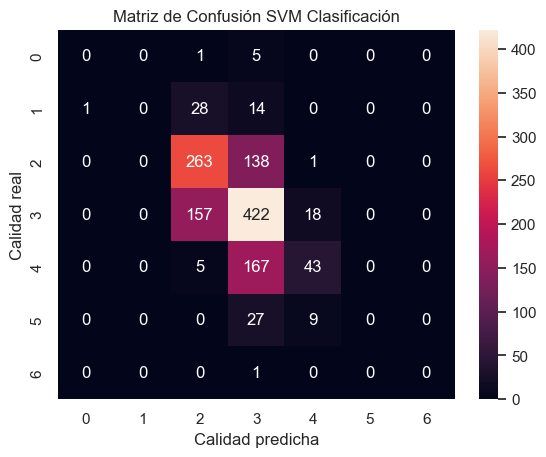

In [92]:
# imprimimos la matriz de confusion
cm_svm = confusion_matrix(y_test, y_pred_svm_clf)
sns.heatmap(cm_svm, annot=True, fmt="d")
plt.title("Matriz de Confusión SVM Clasificación")
plt.xlabel("Calidad predicha")
plt.ylabel("Calidad real")
plt.show()

In [93]:
acc_svm_clf = accuracy_score(y_test, y_pred_svm_clf)
print("Accuracy SVM Clasificación:", acc_svm_clf)

Accuracy SVM Clasificación: 0.56


### Resultado

El modelo SVM clasificacion obtiene una exactitud aproximada del 56% en el conjunto de prueba.

## Árbol de Decisión - Clasificación

In [94]:
from sklearn.tree import DecisionTreeClassifier# importamos el modelo

In [95]:
# cremaos el modelo
tree_clf = DecisionTreeClassifier(random_state=42)

In [96]:
# entrenamos el modelo con los datos de entrenamiento
tree_clf.fit(x_train, y_train)  # aqui no se requiere escalado de datos

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [97]:
# predecimos la calidad de los vinos en el conjunto de prueba
y_pred_tree = tree_clf.predict(x_test)

## Classification Report

El `classification_report` nos muestra varias métricas para cada clase: 

- **Precision** : qué porcentaje de predicciones de una clase son correctas  
- **Recall** : qué porcentaje de ejemplos reales detecta el modelo 
- **F1-score** : equilibrio entre precision y recall  
- **Support** : número de ejemplos de cada clase

Esto es útil cuando el dataset está desbalanceado.

In [98]:
# clasification report
print(classification_report(y_test, y_pred_tree, labels=tree_clf.classes_, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.21      0.21      0.21        43
           5       0.60      0.68      0.64       402
           6       0.66      0.58      0.62       597
           7       0.53      0.58      0.56       215
           8       0.35      0.36      0.36        36
           9       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.34      0.34      0.34      1300
weighted avg       0.59      0.59      0.59      1300



Con esto resultados podemos decir que para la calidad de vino 6 por ejemplo:

- Tenemos una **precision** del 66% por lo que cuadno el modelo dice que el vino es de calidad 6 acierta un 66% de las veces

- Para el **recall** de 58% podemos decir: el modelo detecta correctamente que el 58% es de los vinos de calidad 6

- F1-score es una combinacion entre precision y recall cuanto mas cerca del 1 mejor

- Por ultimo support, este nos dice que para la calidad 6 de vinos tenemos 597 vinos



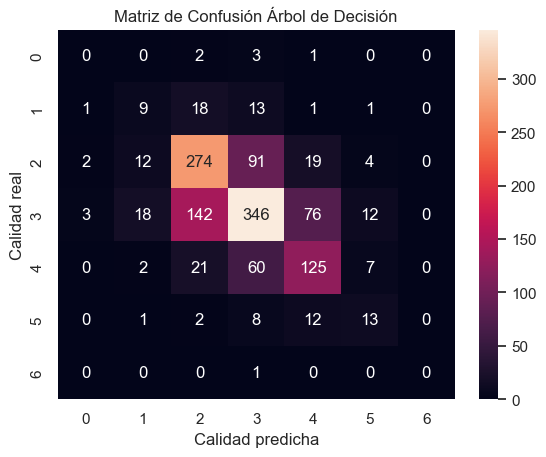

In [99]:
# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt="d")
plt.title("Matriz de Confusión Árbol de Decisión")
plt.xlabel("Calidad predicha")
plt.ylabel("Calidad real")
plt.show()

In [100]:
# exactitud del modelo
acc_tree = accuracy_score(y_test, y_pred_tree)
print("Accuracy Árbol de Decisión:", acc_tree)

Accuracy Árbol de Decisión: 0.59


### Resultado

El modelo Arbol de Decision de Clasificacion obtiene una exactitud aproximada del 59% en el conjunto de prueba.

## Random Forest - Clasificación

In [101]:
from sklearn.ensemble import RandomForestClassifier# importamos el modelo

In [102]:
# creamos el modelo Random Forest para clasificación
rf_clf = RandomForestClassifier(random_state=42)

In [103]:
# entrenamos el modelo
rf_clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [104]:
# predecimos
y_pred_rf = rf_clf.predict(x_test)

## Classification Report

El `classification_report` nos muestra varias métricas para cada clase: 

- **Precision** : qué porcentaje de predicciones de una clase son correctas  
- **Recall** : qué porcentaje de ejemplos reales detecta el modelo 
- **F1-score** : equilibrio entre precision y recall  
- **Support** : número de ejemplos de cada clase

Esto es útil cuando el dataset está desbalanceado.

In [105]:
# classification report
print(classification_report(y_test, y_pred_rf, labels=rf_clf.classes_, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.71      0.12      0.20        43
           5       0.67      0.71      0.69       402
           6       0.66      0.75      0.70       597
           7       0.71      0.55      0.62       215
           8       0.92      0.33      0.49        36
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1300
   macro avg       0.52      0.35      0.39      1300
weighted avg       0.67      0.67      0.66      1300



Con esto resultados podemos decir que para la calidad de vino 6 por ejemplo:

- Tenemos una **precision** del 66% por lo que cuadno el modelo dice que el vino es de calidad 6 acierta un 66% de las veces

- Para el **recall** de 75% podemos decir: el modelo detecta correctamente que el 75% es de los vinos de calidad 6

- F1-score es una combinacion entre precision y recall cuanto mas cerca del 1 mejor

- Por ultimo support, este nos dice que para la calidad 6 de vinos tenemos 597 vinos



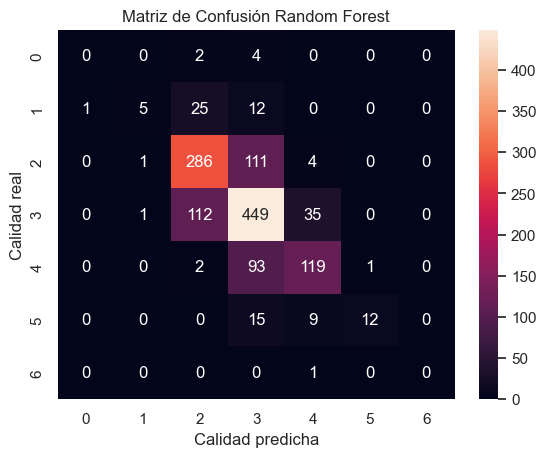

In [106]:
# matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Matriz de Confusión Random Forest")
plt.xlabel("Calidad predicha")
plt.ylabel("Calidad real")
plt.show()

In [107]:
# exactitud
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.67


### Resultado

El modelo Random Forest clasificacion obtiene una exactitud aproximada del 67% en el conjunto de prueba.

## Comparación de modelos de clasificación

Después de entrenar y evaluar los modelos de clasificación, podemos comparar su rendimiento utilizando la métrica de exactitud (accuracy).

- **KNN Clasificacion** tuvo una exactitud de aproximadamente **0.68**, que seria el **68% de los casos**.

- **Naive Bayes** tuvo una exactitud de aproximadamente **0.47**, que seria el **46% de los casos**.

- **SVM Clasificacion** tuvo una exactitud de aproximadamente **0.56**, que seria el **56% de los casos**.

- **Arbol Decision Clasificacion** tuvo una exactitud de aproximadamente **0.59**, que seria el **59% de los casos**.

- **Random Forest Clasificacion** tuvo una exactitud de aproximadamente **0.67**, que seria el **67% de los casos**.

A partir de estos resultados podemos observar que **KNN y Random Forest tienen un mejor rendimiento para este problema de clasificación**.

## KNN - REGRESION

Usamos knn otra vez pero esta vez para el modelo de regresión

Para evaluar el modelo utilizaremos varias métricas de regresión como:
- **MAE (Mean Absolute Error)** : error medio absoluto
- **MSE (Mean Squared Error)** : error cuadrático medio
- **R2** : coeficiente de determinación

In [108]:
# importamos el modelo KNN para regresión
from sklearn.neighbors import KNeighborsRegressor

# importamos métricas para evaluar el modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [109]:
neighbors_range = range(1, 31)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan', 'minkowski']

best_score = float('-inf')# inicializamos en -infinito para ir guardando el mejor resultado
best_params = {}

for weight in weights_options:
    for metric_option in metric_options:
        for neighbors in neighbors_range:

            knn = KNeighborsRegressor(n_neighbors=neighbors, weights=weight, metric=metric_option)

            scores = cross_val_score(knn, x_train_scaled, y_train, cv=4, scoring='neg_mean_absolute_error')# usamos mae en negativo
            mean_score = scores.mean()

            if mean_score > best_score:
                best_score = mean_score
                best_params = {'n_neighbors': neighbors, 'weights': weight, 'metric': metric_option}

print("Best parameters:", best_params)
print("Best cross-validation score (con mae negativo):", best_score)

Best parameters: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'manhattan'}
Best cross-validation score (con mae negativo): -0.4286715289599501


In [110]:
# creamos el modelo de regresion con los mejores parametros y lo guardamos en knn_reg
knn_reg = KNeighborsRegressor(n_neighbors=best_params['n_neighbors'], weights=best_params['weights'], metric=best_params['metric'])

In [111]:

knn_reg.fit(x_train_scaled, y_train)# entrenamos el modelo con los datos de entrenamiento ya escalados

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [112]:
y_pred_reg = knn_reg.predict(x_test_scaled)# predecimos el modelo 

Segun los resultados vamos a ver como predice la calidad de los vinos:

- **MAE** - error medio absoluto, nos dice cuanto se equivoca en promedio, cuanto mas cerca del 0 mejor.  
- **MSE** - error cuadrático medio, tienen más peso los errores grandes, cuanto mas cerca del 0 mejor.  
- **R2** - explica cuanto es capaz de predecir, cuanto mas cerca del 1 mejor.

In [113]:
# calculamos diferentes métricas para evaluar el modelo usando los valores reales de calidad y los que hemos predicho
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

# mostramos los resultados
print("KNN MAE:", mae)
print("KNN MSE:", mse)
print("KNN R2:", r2)

KNN MAE: 0.40475666674452837
KNN MSE: 0.3790396252178869
KNN R2: 0.4867763922926931


Según los resultados:

- MAE - el modelo se equivoca en 0.4 puntos de calidad.
- MSE - los errores grandes no son muy frecuentes.
- R2 - no es muy bueno pero predice algo.

## SVM - REGRESIÓN

Ahora vamos a usar SVM (Support Vector Machine) para predecir la calidad de los vinos como un valor numérico.

In [114]:
# importamos el modelo de SVM para regresión
from sklearn.svm import SVR

In [115]:
# creamos el modelo SVM para regresión
svm_reg = SVR(kernel='rbf')

In [116]:
# entrenamos el modelo con los datos de entrenamiento
svm_reg.fit(x_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [117]:
# predecimos la calidad del vino
y_pred_svm = svm_reg.predict(x_test_scaled)

## Metricas

Ahora vamos a ver qué tan bien nuestro modelo KNN de regresión predice la calidad de los vinos usando métricas fáciles de interpretar:

- **MAE** : error medio absoluto, nos dice cuanto se equivoca en promedio, cuanto mas cerca del 0 mejor.  
- **MSE** : error cuadrático medio, tienen más peso los errores grandes, cuanto mas cerca del 0 mejor.  
- **R2** : explica cuanto es capaz de predecir, cuanto mas cerca del 1 mejor.

In [118]:
# calculamos las métricas para evaluar el modelo
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("SVM MAE:", mae_svm)
print("SVM MSE:", mse_svm)
print("SVM R2:", r2_svm)

SVM MAE: 0.5126235598895458
SVM MSE: 0.4599034116444077
SVM R2: 0.3772859816823628


Según los resultados:

- MAE - el modelo se equivoca 0.51 que es como medio punto de calidad.
- MSE - los errores grandes no son muy frecuentes.
- R2 - no es muy bueno pero predice algo de la calidad del vino.

## Árbol de Decisión - Regresión

In [119]:
from sklearn.tree import DecisionTreeRegressor# importamos el modelo

In [120]:
# creamos el modelo de Árbol de Decisión para regresión
tree_reg = DecisionTreeRegressor(random_state=42)

In [121]:
# entrenamos el modelo con los datos de entrenamiento
tree_reg.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [122]:
# predecimos la calidad de los vinos en el conjunto de prueba
y_pred_tree_reg = tree_reg.predict(x_test)

## Metricas

Ahora vamos a ver qué tan bien nuestro modelo KNN de regresión predice la calidad de los vinos usando métricas fáciles de interpretar:

- **MAE** : error medio absoluto, nos dice cuanto se equivoca en promedio, cuanto mas cerca del 0 mejor.  
- **MSE** : error cuadrático medio, tienen más peso los errores grandes, cuanto mas cerca del 0 mejor.  
- **R2** : explica cuanto es capaz de predecir, cuanto mas cerca del 1 mejor.

In [123]:
# evaluamos el modelo usando métricas de regresión
mae_tree = mean_absolute_error(y_test, y_pred_tree_reg)
mse_tree = mean_squared_error(y_test, y_pred_tree_reg)
r2_tree = r2_score(y_test, y_pred_tree_reg)

print("Arbol decision MAE:", mae_tree)
print("Arbol decision MSE:", mse_tree)
print("Arbol decision R2:", r2_tree)

Arbol decision MAE: 0.5084615384615384
Arbol decision MSE: 0.7284615384615385
Arbol decision R2: 0.013655475650245497


Según los resultados:

- MAE - el modelo se equivoca aproximadamente en 0.5 puntos de calidad.
- MSE - los errores grandes aparecen más que en otros modelos.
- R2 - es muy bajo, lo que indica que el modelo casi no predice la calidad del vino.

## Random Forest - Regresión

In [124]:
from sklearn.ensemble import RandomForestRegressor# importamos el modelo

In [125]:
# creamos el modelo Random Forest para regresión
rf_reg = RandomForestRegressor(random_state=42)

In [126]:
# entrenamos el modelo
rf_reg.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [127]:
# predicción
y_pred_rf_reg = rf_reg.predict(x_test)

## Metricas

Ahora vamos a ver qué tan bien nuestro modelo KNN de regresión predice la calidad de los vinos usando métricas fáciles de interpretar:

- **MAE** : error medio absoluto, nos dice cuanto se equivoca en promedio, cuanto mas cerca del 0 mejor.  
- **MSE** : error cuadrático medio, tienen más peso los errores grandes, cuanto mas cerca del 0 mejor.  
- **R2** : explica cuanto es capaz de predecir, cuanto mas cerca del 1 mejor.

In [128]:
# evaluamos
mae_rf = mean_absolute_error(y_test, y_pred_rf_reg)
mse_rf = mean_squared_error(y_test, y_pred_rf_reg)
r2_rf = r2_score(y_test, y_pred_rf_reg)

print("Random forest MAE:", mae_rf)
print("Random forest MSE:", mse_rf)
print("Random forest R2:", r2_rf)

Random forest MAE: 0.4378538461538462
Random forest MSE: 0.3713522307692308
Random forest R2: 0.49718520459177784


Según los resultados:

- MAE - el modelo se equivoca 0.43 puntos de calidad.
- MSE - los errores grandes no son muy frecuentes.
- R2 - no es muy bueno pero predice algo de la calidad del vino.

## Comparación de modelos de regresión

Después de entrenar y evaluar los modelos de regresión podemos comparar su rendimiento utilizando las métricas MAE, MSE y R2.

### Resultados

**KNN Regresion**

- MAE: 0.40
- MSE: 0.37
- R2: 0.48

**SVM Regresion**

- MAE: 0.51
- MSE: 0.45
- R2: 0.37

**Arbol Decision Regresion**

- MAE: 0.50
- MSE: 0.72
- R2: 0.01

**Random Forest Regresion**

- MAE: 0.43
- MSE: 0.37
- R2: 0.49

Se puede decir que el modelo **KNN y Random Forest son los que obtienen mejores resultados en todas las métricas**.

Esto indica que **KNN y Random Forest se adaptan mejor a la estructura del dataset** para este problema de regresión.

# Justificación de elección de algoritmos

## Clasificación:

- Se probaron KNN, Naive Bayes, SVM, Árbol de Decisión y Random Forest.

- KNN obtuvo mayor accuracy (68%) y mejores métricas.

- Naive Bayes fue más bajo (46%).

- SVM y Árbol de Decisión tuvieron valores intermedios (56% y 59%), mientras que Random Forest logró un rendimiento cercano al de KNN (67%).

### Conclusión: 

- KNN es más adecuado para clasificación en este dataset.

- Random Forest también funciona bien y podría considerarse como alternativa.


## Regresión:

- Se probaron KNN, SVM, Árbol de Decisión y Random Forest.

- KNN y Random Forest obtuvieron los mejores resultados en MAE, MSE y R2.

- SVM predijo peor y el arbol de decision tuvo un R2 casi nulo (0.01), esto indica que casi no predice la calidad del vino.

### Conclusión: 

- Para regresión, KNN y Random Forest son los modelos más adecuados.

- SVM y Árbol de Decisión funcionan, pero predicen con mayor error.

# Conclusión final

- KNN es el algoritmo más adecuado tanto para clasificación como para regresión en este conjunto de datos, ya que obtuvo los mejores resultados en precisión y métricas de error.

- Random Forest también mostró buen desempeño, especialmente en regresión, y podría considerarse como una alternativa válida.

- SVM, Naive Bayes y Árbol de Decisión son opciones viables, pero predicen con mayor error o menor exactitud, y por eso son menos recomendables para este dataset.